# Data augmentation
We can improve robustness and validation accuracy by augmenting only the training images while leaving the test pipeline unchanged. Simple geometric transforms (cropping, rotation, translation) and regularization transforms (jitter, random erase) expose the model to realistic variations without changing labels. See e.g. [Shorten & Khoshgoftaar, 2021](https://www.sciencedirect.com/science/article/pii/S2590005622000911).


In [14]:
train_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
])

test_transform = transforms.ToTensor()

train_ds = datasets.MNIST(root="../data", train=True, download=True, transform=train_transform)
test_ds = datasets.MNIST(root="../data", train=False, download=True, transform=test_transform)

batch_size = 50
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
model = FeedForwardNet().to(device)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()


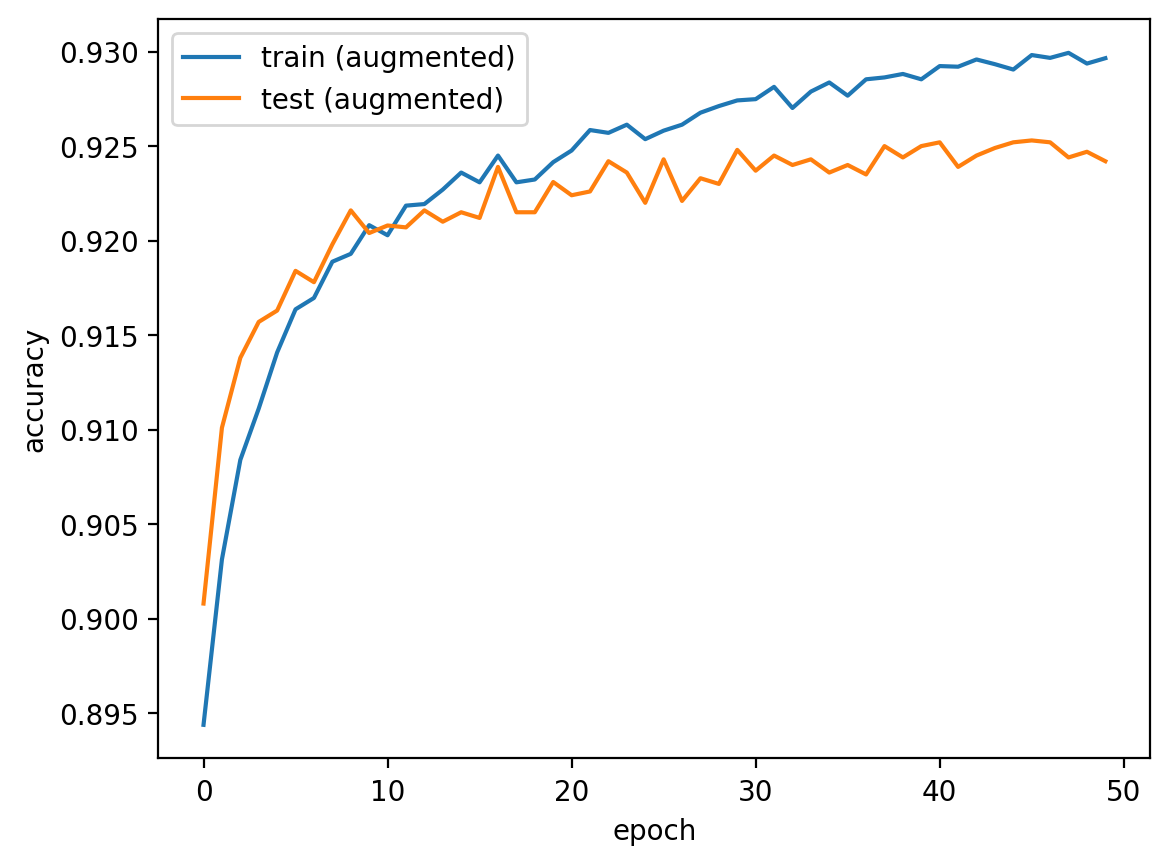

In [15]:
plt.plot(metrics['train_accuracy'][1:], label='train (augmented)')
plt.plot(metrics['val_accuracy'][1:], label='test (augmented)')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend();
